In [5]:
import pandas as pd
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score

# ==========================================
# Create Dataset
# ==========================================

data = {
    "customerID": [
        "7590-VHVEG",
        "5575-GNVDE",
        "3668-QPYBK",
        "7795-CFOCW",
        "9237-HQITU"
    ],

    "gender": [
        "Female",
        "Male",
        "Male",
        "Male",
        "Female"
    ],

    "SeniorCitizen": [
        0,
        0,
        0,
        0,
        0
    ],

    "Partner": [
        "Yes",
        "No",
        "No",
        "No",
        "No"
    ],

    "Dependents": [
        "No",
        "No",
        "No",
        "No",
        "No"
    ],

    "tenure": [
        1,
        34,
        2,
        45,
        2
    ],

    "PhoneService": [
        "No",
        "Yes",
        "Yes",
        "No",
        "Yes"
    ],

    "InternetService": [
        "DSL",
        "DSL",
        "DSL",
        "DSL",
        "Fiber optic"
    ],

    "MonthlyCharges": [
        29.85,
        56.95,
        53.85,
        42.30,
        70.70
    ],

    "TotalCharges": [
        29.85,
        1889.50,
        108.15,
        1840.75,
        151.65
    ],

    "Churn": [
        "No",
        "No",
        "Yes",
        "No",
        "Yes"
    ]
}

# ==========================================
# Convert to DataFrame
# ==========================================

df = pd.DataFrame(data)

print(df.head())

# ==========================================
# Encode Categorical Columns
# ==========================================

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

# ==========================================
# Features and Target
# ==========================================

X = df.drop('Churn', axis=1)
y = df['Churn']

# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Models
# ==========================================

lr = LogisticRegression(max_iter=5000)

dt = DecisionTreeClassifier()

rf = RandomForestClassifier()

svm = SVC(probability=True)

# ==========================================
# Voting Ensemble
# ==========================================

model = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('rf', rf),
        ('svm', svm)
    ],
    voting='soft'
)

# ==========================================
# Train Model
# ==========================================

model.fit(X_train, y_train)

# ==========================================
# Prediction
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# Accuracy
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# ==========================================
# Create models folder
# ==========================================

os.makedirs("models", exist_ok=True)

# ==========================================
# Save Model
# ==========================================

joblib.dump(model, 'models/voting_model.pkl')

print("Model Saved Successfully")

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

  InternetService  MonthlyCharges  TotalCharges Churn  
0             DSL           29.85         29.85    No  
1             DSL           56.95       1889.50    No  
2             DSL           53.85        108.15   Yes  
3             DSL           42.30       1840.75    No  
4     Fiber optic           70.70        151.65   Yes  
Accuracy: 0.0
Model Saved Successfully


[[0 1]
 [0 0]]


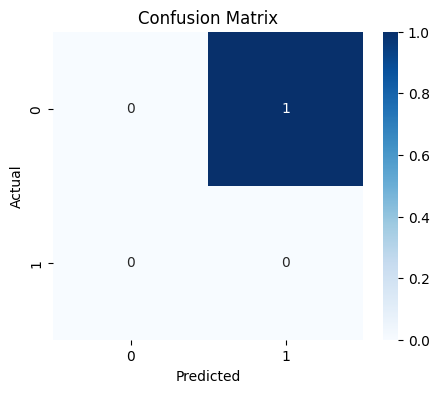

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

# Plot
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

C:\Users\Sagar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


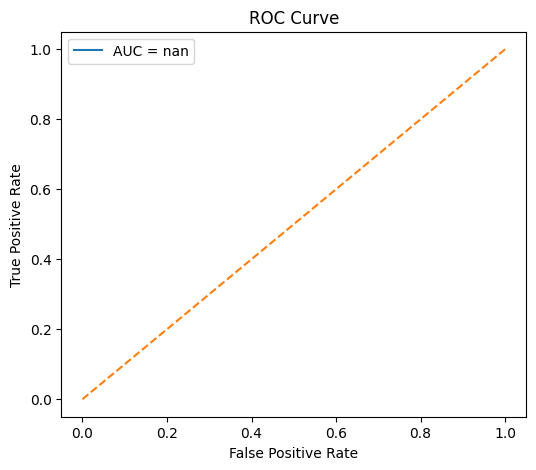

In [7]:
from sklearn.metrics import roc_curve, auc

# Probability prediction
y_prob = model.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

           Feature  Importance
8   MonthlyCharges    0.291165
9     TotalCharges    0.160643
0       customerID    0.124498
6     PhoneService    0.120482
3          Partner    0.112450
5           tenure    0.090361
7  InternetService    0.064257
1           gender    0.036145
4       Dependents    0.000000
2    SeniorCitizen    0.000000


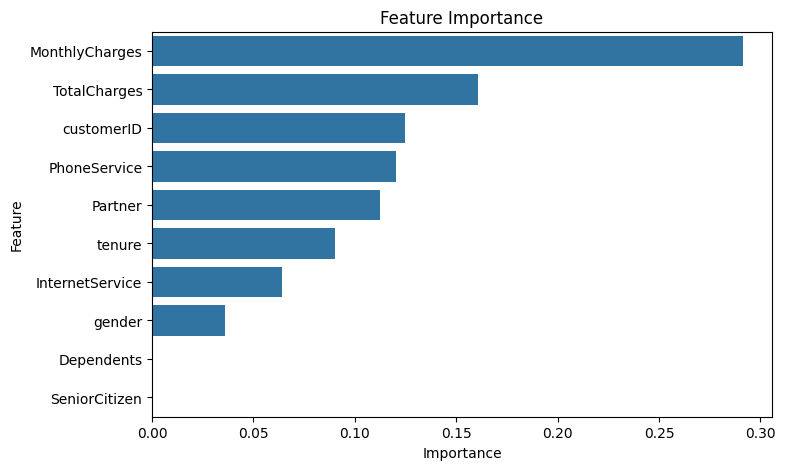

In [8]:
# Train Random Forest separately
rf.fit(X_train, y_train)

# Feature Importance
importance = rf.feature_importances_

# Create DataFrame
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort
feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_df)

# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance")

plt.show()

In [10]:
import gradio as gr
import pandas as pd
import joblib

# ==========================================
# Load Model
# ==========================================

model = joblib.load("models/voting_model.pkl")

# ==========================================
# Prediction Function
# ==========================================

def predict_churn(
    gender,
    senior_citizen,
    tenure,
    monthly_charges,
    total_charges
):

    # Create DataFrame
    data = pd.DataFrame([{
        'gender': 1 if gender == "Male" else 0,
        'SeniorCitizen': senior_citizen,
        'tenure': tenure,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges
    }])

    # Add missing columns
    required_columns = model.feature_names_in_

    for col in required_columns:
        if col not in data.columns:
            data[col] = 0

    # Reorder columns
    data = data[required_columns]

    # Prediction
    prediction = model.predict(data)[0]

    # Result
    if prediction == 1:
        return "❌ Customer Will Churn"

    return "✅ Customer Will Stay"

# ==========================================
# Gradio Interface
# ==========================================

interface = gr.Interface(
    fn=predict_churn,

    inputs=[
        gr.Radio(
            ["Male", "Female"],
            label="Gender"
        ),

        gr.Number(label="Senior Citizen"),

        gr.Number(label="Tenure"),

        gr.Number(label="Monthly Charges"),

        gr.Number(label="Total Charges")
    ],

    outputs="text",

    title="📊 Customer Churn Prediction AI",

    description="Voting Ensemble Machine Learning Project"
)

# ==========================================
# Launch App
# ==========================================

interface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
